# 2.7 병렬 처리를 통한 효율 개선 (feat. 프롬프트 엔지니어링)

- 아주 specific한 에이전트를 개발하는 경우 유리합니다 
- 답변을 생성할 때 다양한 정보가 필요하다면 병렬 처리를 통해 시간을 절약할 수 있습니다

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str # 사용자 질문
    answer: str # 세율
    tax_base_equation: str # 과세표준 계산 수식 
    tax_deduction: str # 공제액 
    market_ratio: str # 공정시장가액비율
    tax_base: str # 과세표준 계산
    
graph_builder = StateGraph(AgentState)

In [3]:
import os 

from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [21]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [6]:
from langchain_openai import ChatOpenAI
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = hub.pull('rlm/rag-prompt')

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

c:\Users\dev-euna\Desktop\AI_AGENT_STUDY\langgraph-agent\.venv\Lib\site-packages\langsmith\client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [10]:

tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_prompt
    | small_llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information' : tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(state: AgentState) -> AgentState:
    """
    종합부동산세 과세표준을 계산하는 수식을 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.

    Args:
        state (AgentState): 현재 에이전트의 상태를 나타내는 객체입니다.

    Returns:
        AgentState: 'tax_base_equation' 키를 포함하는 새로운 `state`를 반환합니다.
    """
    # 과세표준을 계산하는 방법을 묻는 질문을 정의합니다.
    tax_base_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    
    # tax_base_chain을 사용하여 질문을 실행하고 결과를 얻습니다.
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    
    # state에서 'tax_base_equation' 키에 대한 값을 반환합니다.
    return {'tax_base_equation': tax_base_equation}

In [ ]:
get_tax_base_equation({})
#{'tax_base_equation': '과세표준 = (∑(주택의 공시가격) - 공제액) × 공정시장가액비율'}

{'tax_base_equation': '과세표준 = (∑(주택의 공시가격) - 공제액) × 공정시장가액비율'}

In [13]:

tax_deduction_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState) -> AgentState:
    """
    종합부동산세 공제금액에 관한 정보를 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'tax_deduction' 키를 포함하는 새로운 state를 반환합니다.
    """
    # 공제금액을 묻는 질문을 정의합니다.
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
    
    # tax_deduction_chain을 사용하여 질문을 실행하고 결과를 얻습니다.
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    
    # state에서 'tax_deduction' 키에 대한 값을 반환합니다.
    return {'tax_deduction': tax_deduction}

In [ ]:
get_tax_deduction({})
# {'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 1세대 1주택자의 경우 12억 원, 법인 및 법인으로 보는 단체는 6억 원, 그 외의 경우는 9억 원입니다.'}

{'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 1세대 1주택자의 경우 12억 원, 법인 및 법인으로 보는 단체는 6억 원, 그 외의 경우는 9억 원입니다.'}

In [15]:
from langchain_community.tools import TavilySearchResults
from datetime import date

tavily_search_tool = TavilySearchResults(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', f'아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}'),
    ('human', '{query}')
])

def get_market_ratio(state: AgentState) -> AgentState:
    """
    web 검색을 통해 주택 공시가격(대통령령)에 대한 공정시장가액비율을 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.
    
    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'market_ratio' 키를 포함하는 새로운 state를 반환합니다.
    """
    # 오늘 날짜에 해당하는 공정시장가액비율을 묻는 쿼리를 정의합니다.
    query = f'오늘 날짜:({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?'
    
    # tavily_search_tool을 사용하여 쿼리를 실행하고 컨텍스트를 얻습니다.
    context = tavily_search_tool.invoke(query)
    
    # tax_market_ratio_chain을 구성하여 쿼리와 컨텍스트를 처리합니다.
    tax_market_ratio_chain = (
        tax_market_ratio_prompt
        | llm
        | StrOutputParser()
    )
    
    # tax_market_ratio_chain을 사용하여 시장 비율을 계산합니다.
    market_ratio = tax_market_ratio_chain.invoke({'context': context, 'query': query})
    
    # state에서 'market_ratio' 키에 대한 값을 반환합니다.
    return {'market_ratio': market_ratio}

In [ ]:
get_market_ratio({})
{'market_ratio': '2026년 기준으로 주택의 공정시장가액비율은 일반적으로 60%입니다. 하지만 1세대 1주택자의 경우, 공시가격에 따라 특례 공정시장가액비율이 적용됩니다. 구체적으로:\n\n- 공시가격 3억 원 이하: 43%\n- 공시가격 3억 원 초과 ~ 6억 원 이하: 44%\n- 공시가격 6억 원 초과: 45%\n\n따라서, 일반적인 경우에는 60%의 공정시장가액비율이 적용되며, 1세대 1주택자는 공시가격에 따라 위의 특례 비율이 적용됩니다.'}

{'market_ratio': '2026년 기준으로 주택의 공정시장가액비율은 일반적으로 60%입니다. 하지만 1세대 1주택자의 경우, 공시가격에 따라 특례 공정시장가액비율이 적용됩니다. 구체적으로:\n\n- 공시가격 3억 원 이하: 43%\n- 공시가격 3억 원 초과 ~ 6억 원 이하: 44%\n- 공시가격 6억 원 초과: 45%\n\n따라서, 일반적인 경우에는 60%의 공정시장가액비율이 적용되며, 1세대 1주택자는 공시가격에 따라 위의 특례 비율이 적용됩니다.'}

In [23]:
tax_base_calculation_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',"""
주어진 내용을 기반으로 과세표준을 계산해주세요

과세표준 계산 공식: {tax_base_equation}
공제금액: {tax_deduction}
공정시장가액비율: {market_ratio}"""),
        ('human', '사용자 주택 공시가격 정보: {query}')
    ]
)

def calculate_tax_base(state: AgentState) -> AgentState:
    """
    주어진 state에서 과세표준을 계산합니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'tax_base' 키를 포함하는 새로운 state를 반환합니다.
    """
    # state에서 필요한 정보를 추출합니다.
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']
    
    # tax_base_calculation_chain을 구성하여 과세표준을 계산합니다.
    tax_base_calculation_chain = (
        tax_base_calculation_prompt
        | llm
        | StrOutputParser()
    )
    
    # tax_base_calculation_chain을 사용하여 과세표준을 계산합니다.
    tax_base = tax_base_calculation_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query
    })

    print(f'tax_base == {tax_base}')

    # state에서 'tax_base' 키에 대한 값을 반환합니다.
    return {'tax_base': tax_base}

In [24]:
initial_state = {
    'query': query,
    'tax_base_equation': '과세표준 = (∑(주택의 공시가격) - 공제액) × 공정시장가액비율',
    'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 1세대 1주택자의 경우 12억 원, 법인 및 법인으로 보는 단체는 6억 원, 그 외의 경우는 9억 원입니다.',
    'market_ratio': '2026년 기준으로 주택의 공정시장가액비율은 일반적으로 60%입니다. 하지만 1세대 1주택자의 경우, 공시가격에 따라 특례 공정시장가액비율이 적용됩니다. 구체적으로:\n\n- 공시가격 3억 원 이하: 43%\n- 공시가격 3억 원 초과 ~ 6억 원 이하: 44%\n- 공시가격 6억 원 초과: 45%\n\n따라서, 일반적인 경우에는 60%의 공정시장가액비율이 적용되며, 1세대 1주택자는 공시가격에 따라 위의 특례 비율이 적용됩니다.'
}

calculate_tax_base(initial_state)

tax_base == 주어진 정보를 바탕으로 과세표준을 계산해보겠습니다.

1. 주택의 총 공시가격 합계:  
   \(5억 원 + 10억 원 + 20억 원 = 35억 원\)

2. 공제액:  
   사용자가 법인이나 1세대 1주택자가 아닌 경우, 공제액은 9억 원입니다.

3. 공정시장가액비율:  
   사용자가 1세대 1주택자가 아닌 경우, 일반적인 공정시장가액비율인 60%가 적용됩니다.

과세표준 계산:  
\[
\text{과세표준} = (35억 원 - 9억 원) \times 60\%
\]
\[
= 26억 원 \times 0.6 = 15.6억 원
\]

따라서, 과세표준은 15.6억 원입니다. 이 과세표준을 바탕으로 종합부동산세가 계산됩니다. 종합부동산세율은 과세표준 구간에 따라 다르므로, 정확한 세금 금액을 계산하려면 세율표를 참고해야 합니다.


{'tax_base': '주어진 정보를 바탕으로 과세표준을 계산해보겠습니다.\n\n1. 주택의 총 공시가격 합계:  \n   \\(5억 원 + 10억 원 + 20억 원 = 35억 원\\)\n\n2. 공제액:  \n   사용자가 법인이나 1세대 1주택자가 아닌 경우, 공제액은 9억 원입니다.\n\n3. 공정시장가액비율:  \n   사용자가 1세대 1주택자가 아닌 경우, 일반적인 공정시장가액비율인 60%가 적용됩니다.\n\n과세표준 계산:  \n\\[\n\\text{과세표준} = (35억 원 - 9억 원) \\times 60\\%\n\\]\n\\[\n= 26억 원 \\times 0.6 = 15.6억 원\n\\]\n\n따라서, 과세표준은 15.6억 원입니다. 이 과세표준을 바탕으로 종합부동산세가 계산됩니다. 종합부동산세율은 과세표준 구간에 따라 다르므로, 정확한 세금 금액을 계산하려면 세율표를 참고해야 합니다.'}

In [28]:
tax_rate_calculation_prompt = ChatPromptTemplate.from_messages([
    ('system', '''당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요

종합부동산세 세율:{context}'''),
    ('human', '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요

과세표준: {tax_base}
주택 수:{query}''')
])

def calculate_tax_rate(state: AgentState):
    """
    주어진 state에서 세율을 계산합니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        dict: 'answer' 키를 포함하는 새로운 state를 반환합니다.
    """
    # state에서 필요한 정보를 추출합니다.
    query = state['query']
    tax_base = state['tax_base']
    
    # retriever를 사용하여 쿼리를 실행하고 컨텍스트를 얻습니다.
    context = retriever.invoke(query)
    
    # tax_rate_chain을 구성하여 세율을 계산합니다.
    tax_rate_chain = (
        tax_rate_calculation_prompt
        | llm
        | StrOutputParser()
    )
    
    # tax_rate_chain을 사용하여 세율을 계산합니다.
    tax_rate = tax_rate_chain.invoke({
        'context': context, 
        'tax_base': tax_base, 
        'query': query
    })


    print(f'tax_rate == {tax_rate}')
    # state에서 'answer' 키에 대한 값을 반환합니다.
    return {'answer': tax_rate}

In [26]:
calculate_tax_base(initial_state)

tax_base == 세금을 계산하기 위해 과세표준을 먼저 계산해야 합니다. 주어진 정보에 따르면, 사용자는 3채의 주택을 소유하고 있으며, 이는 1세대 1주택자가 아니므로 일반적인 경우로 간주됩니다. 따라서 공제금액 9억 원과 공정시장가액비율 60%가 적용됩니다.

1. 주택의 공시가격 합계: 5억 + 10억 + 20억 = 35억 원
2. 공제금액: 9억 원
3. 공정시장가액비율: 60%

과세표준 계산:
과세표준 = (∑(주택의 공시가격) - 공제액) × 공정시장가액비율
과세표준 = (35억 - 9억) × 60%
과세표준 = 26억 × 0.6
과세표준 = 15.6억 원

따라서, 과세표준은 15.6억 원입니다. 이 과세표준을 기반으로 종합부동산세를 계산할 수 있습니다. 정확한 세금 액수는 과세표준에 적용되는 세율에 따라 달라지며, 이는 별도의 세율표나 규정에 따라 계산해야 합니다.


{'tax_base': '세금을 계산하기 위해 과세표준을 먼저 계산해야 합니다. 주어진 정보에 따르면, 사용자는 3채의 주택을 소유하고 있으며, 이는 1세대 1주택자가 아니므로 일반적인 경우로 간주됩니다. 따라서 공제금액 9억 원과 공정시장가액비율 60%가 적용됩니다.\n\n1. 주택의 공시가격 합계: 5억 + 10억 + 20억 = 35억 원\n2. 공제금액: 9억 원\n3. 공정시장가액비율: 60%\n\n과세표준 계산:\n과세표준 = (∑(주택의 공시가격) - 공제액) × 공정시장가액비율\n과세표준 = (35억 - 9억) × 60%\n과세표준 = 26억 × 0.6\n과세표준 = 15.6억 원\n\n따라서, 과세표준은 15.6억 원입니다. 이 과세표준을 기반으로 종합부동산세를 계산할 수 있습니다. 정확한 세금 액수는 과세표준에 적용되는 세율에 따라 달라지며, 이는 별도의 세율표나 규정에 따라 계산해야 합니다.'}

In [30]:
tax_base_state = {'tax_base': '세금을 계산하기 위해 과세표준을 먼저 계산해야 합니다. 주어진 정보에 따르면, 사용자는 3채의 주택을 소유하고 있으며, 이는 1세대 1주택자가 아니므로 일반적인 경우로 간주됩니다. 따라서 공제금액 9억 원과 공정시장가액비율 60%가 적용됩니다.\n\n1. 주택의 공시가격 합계: 5억 + 10억 + 20억 = 35억 원\n2. 공제금액: 9억 원\n3. 공정시장가액비율: 60%\n\n과세표준 계산:\n과세표준 = (∑(주택의 공시가격) - 공제액) × 공정시장가액비율\n과세표준 = (35억 - 9억) × 60%\n과세표준 = 26억 × 0.6\n과세표준 = 15.6억 원\n\n따라서, 과세표준은 15.6억 원입니다. 이 과세표준을 기반으로 종합부동산세를 계산할 수 있습니다. 정확한 세금 액수는 과세표준에 적용되는 세율에 따라 달라지며, 이는 별도의 세율표나 규정에 따라 계산해야 합니다.', 'query': query}

calculate_tax_rate(tax_base_state)

tax_rate == 사용자가 3채의 주택을 소유하고 있으며, 주택의 공시가격 합계는 35억 원입니다. 과세표준은 15.6억 원으로 계산되었습니다. 이제 3주택 이상의 경우에 해당하는 세율을 적용하여 종합부동산세를 계산하겠습니다.

과세표준이 15.6억 원인 경우, 3주택 이상 소유자의 세율표에 따르면:

- 12억 원 초과 25억 원 이하 구간에 해당합니다.
- 이 구간의 세율은 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)입니다.

따라서, 과세표준이 15.6억 원일 때의 종합부동산세 계산은 다음과 같습니다:

1. 12억 원을 초과하는 금액 = 15.6억 원 - 12억 원 = 3.6억 원
2. 초과 금액에 대한 세금 = 3.6억 원 × 0.002 = 720만 원
3. 총 종합부동산세 = 960만 원 + 720만 원 = 1,680만 원

따라서, 사용자는 1,680만 원의 종합부동산세를 내야 합니다.


{'answer': '사용자가 3채의 주택을 소유하고 있으며, 주택의 공시가격 합계는 35억 원입니다. 과세표준은 15.6억 원으로 계산되었습니다. 이제 3주택 이상의 경우에 해당하는 세율을 적용하여 종합부동산세를 계산하겠습니다.\n\n과세표준이 15.6억 원인 경우, 3주택 이상 소유자의 세율표에 따르면:\n\n- 12억 원 초과 25억 원 이하 구간에 해당합니다.\n- 이 구간의 세율은 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)입니다.\n\n따라서, 과세표준이 15.6억 원일 때의 종합부동산세 계산은 다음과 같습니다:\n\n1. 12억 원을 초과하는 금액 = 15.6억 원 - 12억 원 = 3.6억 원\n2. 초과 금액에 대한 세금 = 3.6억 원 × 0.002 = 720만 원\n3. 총 종합부동산세 = 960만 원 + 720만 원 = 1,680만 원\n\n따라서, 사용자는 1,680만 원의 종합부동산세를 내야 합니다.'}

- `node`를 추가하고 `edge`로 연결합니다
- 하나의 `node`에서 `edge`를 활영해서 다양한 `node`들을 연결하면 병렬로 작업이 가능합니다

In [31]:
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [ ]:
from langgraph.graph import START, END

# 병렬로 처리
graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')

# 병렬로 처리된 결과를 calculate_tax_base로 전달
graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')
graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [33]:
graph = graph_builder.compile()

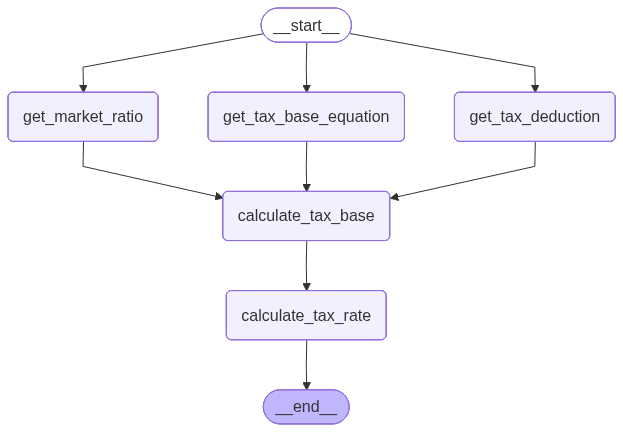

In [34]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
initial_state = {'query': query}
graph.invoke(initial_state)

tax_base == 주어진 정보에 따라 과세표준을 계산해 보겠습니다.

1. 주택 공시가격:
   - 5억 원짜리 집 1채
   - 10억 원짜리 집 1채
   - 20억 원짜리 집 1채

2. 주택 공시가격의 총합: 
   - 5억 + 10억 + 20억 = 35억 원

3. 공제금액:
   - 1세대 1주택자가 아니므로 공제금액은 9억 원입니다.

4. 공정시장가액비율:
   - 공시가격 5억 원: 44%
   - 공시가격 10억 원: 45%
   - 공시가격 20억 원: 45%

   각 주택별로 공정시장가액비율을 적용하여 과세표준을 계산합니다:
   - 5억 원짜리 집: (5억 - 9억) × 44% = 0 (음수일 경우 0으로 처리)
   - 10억 원짜리 집: (10억 - 9억) × 45% = 1억 × 45% = 0.45억 원
   - 20억 원짜리 집: (20억 - 9억) × 45% = 11억 × 45% = 4.95억 원

5. 최종 과세표준:
   - 0 + 0.45억 + 4.95억 = 5.4억 원

따라서, 최종 과세표준은 5.4억 원입니다. 이 금액에 따라 세금이 부과됩니다. 세율은 별도로 제공되지 않았으므로, 과세표준에 세율을 적용하여 실제 세금을 계산해야 합니다.
tax_rate == 주어진 정보에 따라 종합부동산세를 계산해 보겠습니다.

1. **과세표준 계산:**

   최종 과세표준은 5.4억 원입니다. 

2. **소유한 주택 수:**

   주택 수는 총 3채입니다.

3. **세율 적용:**

   3주택 이상 소유한 경우의 세율을 적용합니다. 과세표준 5.4억 원에 해당하는 세율은 다음과 같습니다:

   - 3억 원 초과 6억 원 이하: 150만 원 + (3억 원을 초과하는 금액의 1천분의 7)

   과세표준이 5.4억 원이므로, 3억 원을 초과하는 금액은 2.4억 원입니다. 이를 1천분의 7로 계산하면:

   \[
   150만 원 + (2.4억 원 \times 0.0007) = 150만 원 + 168만 원 = 318만 

{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
 'answer': '주어진 정보에 따라 종합부동산세를 계산해 보겠습니다.\n\n1. **과세표준 계산:**\n\n   최종 과세표준은 5.4억 원입니다. \n\n2. **소유한 주택 수:**\n\n   주택 수는 총 3채입니다.\n\n3. **세율 적용:**\n\n   3주택 이상 소유한 경우의 세율을 적용합니다. 과세표준 5.4억 원에 해당하는 세율은 다음과 같습니다:\n\n   - 3억 원 초과 6억 원 이하: 150만 원 + (3억 원을 초과하는 금액의 1천분의 7)\n\n   과세표준이 5.4억 원이므로, 3억 원을 초과하는 금액은 2.4억 원입니다. 이를 1천분의 7로 계산하면:\n\n   \\[\n   150만 원 + (2.4억 원 \\times 0.0007) = 150만 원 + 168만 원 = 318만 원\n   \\]\n\n따라서, 최종적으로 납부해야 할 종합부동산세는 **318만 원**입니다.',
 'tax_base_equation': '과세표준 = (Σ(주택 공시가격) - 공제액) × 공정시장가액비율',
 'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 다음과 같습니다: 1세대 1주택자는 12억 원, 법인 또는 법인으로 보는 단체는 6억 원, 그 외의 경우는 9억 원이 공제됩니다.',
 'market_ratio': '2026년 기준으로 주택에 적용되는 공정시장가액비율은 일반 보유자는 60%입니다. 1세대 1주택자의 경우에는 공시가격 구간에 따라 다음과 같은 비율이 적용됩니다:\n\n- 공시가격 3억 원 이하: 43%\n- 공시가격 3억 원 초과 ~ 6억 원 이하: 44%\n- 공시가격 6억 원 초과: 45% \n\n따라서 오늘 날짜인 2026년 3월 10일에는 위의 비율이 적용됩니다.',
 'tax_base': '주어진 정보에 따라 과세표준을 계산해 보겠습니다.\n\n1. 주택 공시가격:\